# Cell Intensity Analysis

This notebook analyzes per-cell marker intensities for CD45, CD3E, and CD8a.

## Workflow:
1. Run `scripts/measure_cell_intensities.py` to generate CSV with per-cell measurements
2. Load the CSV in this notebook
3. Visualize distributions, correlations, and cell classifications
4. Export results and figures

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Setup paths
PROJECT_DIR = Path('../')
CSV_PATH = PROJECT_DIR / 'cellpose_output' / 'cell_intensities.csv'

print(f"Loading data from: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} cells")
print(f"\nColumns: {list(df.columns)}")
df.head()

Loading data from: ../cellpose_output/cell_intensities.csv
Loaded 926,005 cells

Columns: ['cell_id', 'CD45_mean', 'CD45_sum', 'CD45_max', 'CD45_positive', 'CD3E_mean', 'CD3E_sum', 'CD3E_max', 'CD3E_positive', 'CD8a_mean', 'CD8a_sum', 'CD8a_max', 'CD8a_positive', 'composite_intensity', 'cell_area']


,cell_id,CD45_mean,CD45_sum,CD45_max,CD45_positive,CD3E_mean,CD3E_sum,CD3E_max,CD3E_positive,CD8a_mean,CD8a_sum,CD8a_max,CD8a_positive,composite_intensity,cell_area
0,1,577.424460,160524.0,5984.0,True,55.769784,15504.0,1037.0,False,289.330935,80434.0,1413.0,True,256462.0,278.0
1,2,846.557252,221798.0,1760.0,True,542.885496,142236.0,2401.0,True,57.545802,15077.0,336.0,True,379111.0,262.0
2,3,165.628852,118259.0,912.0,True,0.000000,0.0,0.0,False,1.917367,1369.0,3.0,False,119628.0,714.0
3,4,1835.671429,385491.0,16203.0,True,34.785714,7305.0,2084.0,False,25.628571,5382.0,330.0,True,398178.0,210.0
4,5,431.825762,2024831.0,2245.0,True,4.920879,23074.0,918.0,False,4.894007,22948.0,72.0,False,2070853.0,4689.0


## 1. Basic Statistics

In [3]:
# Summary statistics
print("=== Summary Statistics ===\n")
print(df.describe())

# Positive cell counts
print("\n=== Positive Cell Counts ===")
for marker in ['CD45', 'CD3E', 'CD8a']:
    n_positive = df[f'{marker}_positive'].sum()
    pct = 100 * n_positive / len(df)
    print(f"{marker}+: {n_positive:,} ({pct:.2f}%)")

=== Summary Statistics ===

             cell_id      CD45_mean      CD45_sum       CD45_max  \
count  926005.000000  926005.000000  9.260050e+05  926005.000000   
mean   463003.000000     363.642155  1.557867e+05    1383.688240   
std    267314.762348     625.411072  3.246102e+05    1869.067447   
min         1.000000       0.000000  0.000000e+00       0.000000   
25%    231502.000000      26.006079  7.311000e+03     344.000000   
50%    463003.000000      96.524631  3.302900e+04     551.000000   
75%    694504.000000     391.149201  1.557960e+05    1681.000000   
max    926005.000000   24349.082759  6.539862e+07   42956.000000   

           CD3E_mean      CD3E_sum       CD3E_max      CD8a_mean  \
count  926005.000000  9.260050e+05  926005.000000  926005.000000   
mean     1394.918540  5.935892e+05    5479.288994     867.212542   
std      3207.492505  1.444067e+06   10263.848003    1857.974161   
min         0.000000  0.000000e+00       0.000000       0.000000   
25%        15.44236

## 2. Intensity Distributions

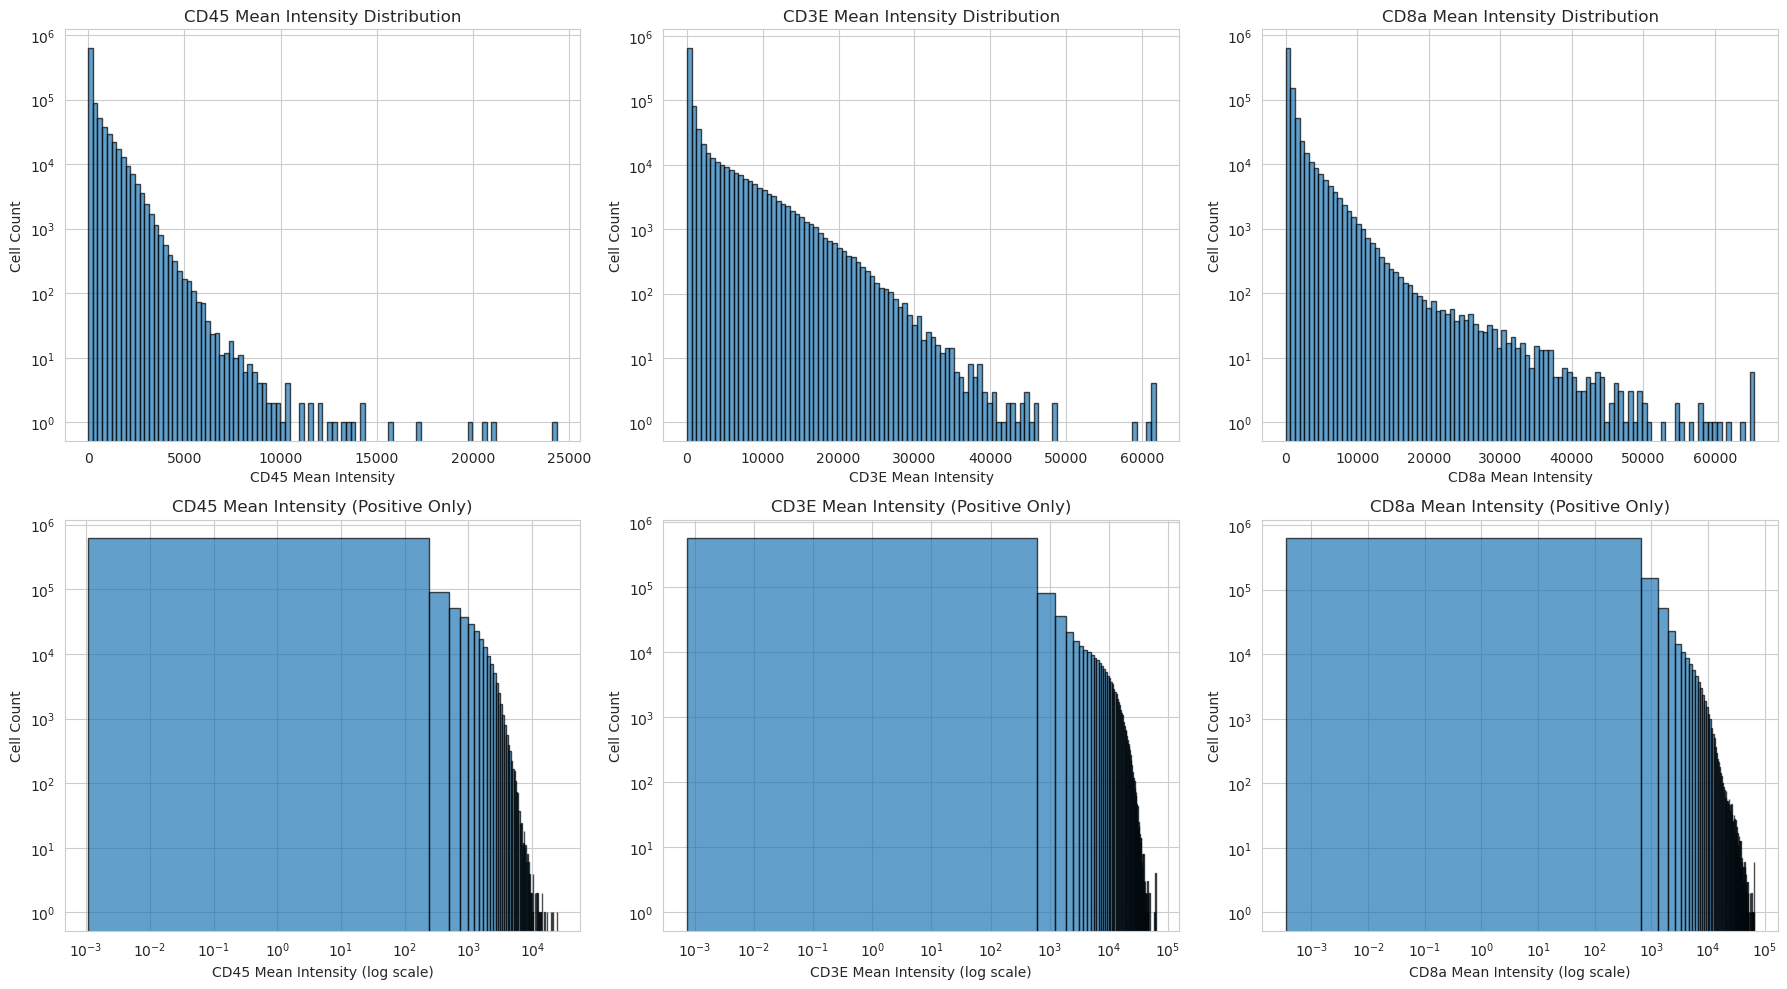

In [4]:
# Plot intensity distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

markers = ['CD45', 'CD3E', 'CD8a']
for i, marker in enumerate(markers):
    # Mean intensity distribution
    ax = axes[0, i]
    ax.hist(df[f'{marker}_mean'], bins=100, alpha=0.7, edgecolor='black')
    ax.set_xlabel(f'{marker} Mean Intensity')
    ax.set_ylabel('Cell Count')
    ax.set_title(f'{marker} Mean Intensity Distribution')
    ax.set_yscale('log')
    
    # Log scale for clarity
    ax = axes[1, i]
    non_zero = df[df[f'{marker}_mean'] > 0][f'{marker}_mean']
    if len(non_zero) > 0:
        ax.hist(non_zero, bins=100, alpha=0.7, edgecolor='black')
        ax.set_xlabel(f'{marker} Mean Intensity (log scale)')
        ax.set_ylabel('Cell Count')
        ax.set_title(f'{marker} Mean Intensity (Positive Only)')
        ax.set_xscale('log')
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 3. Marker Correlations

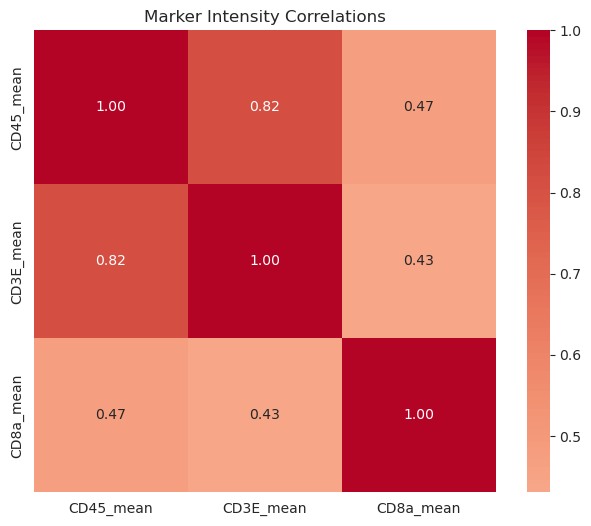

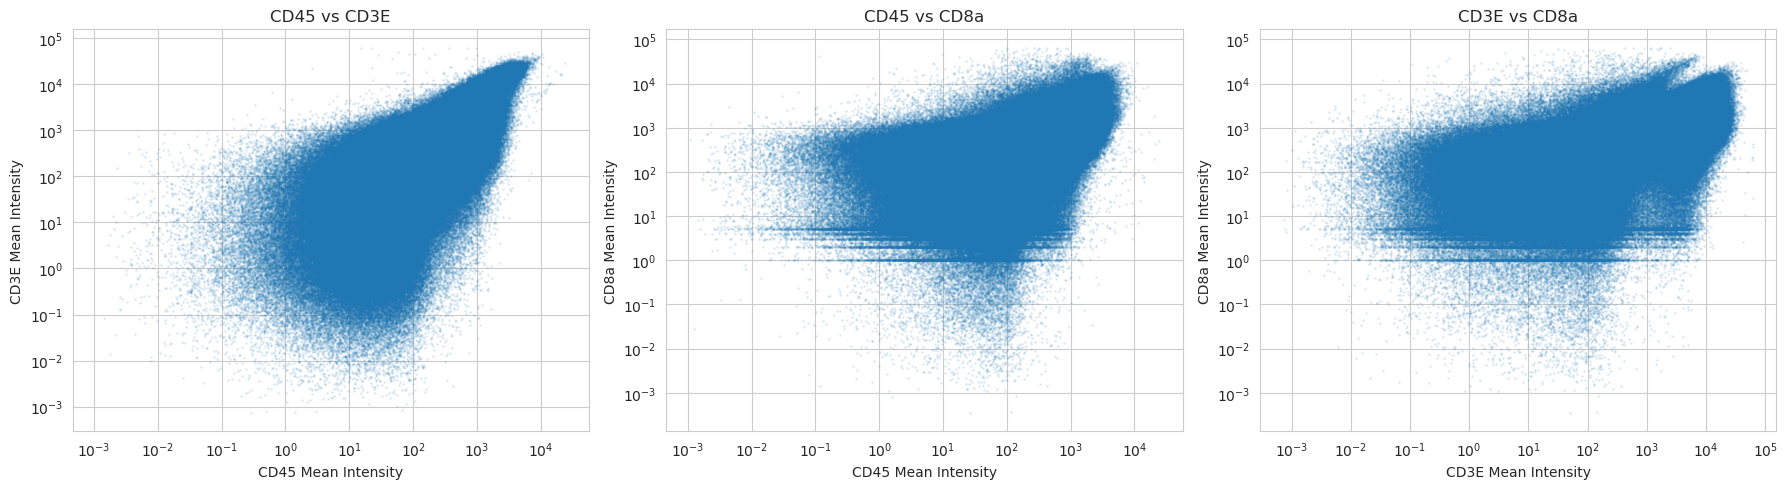

In [5]:
# Correlation matrix
intensity_cols = [f'{m}_mean' for m in markers]
corr_matrix = df[intensity_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax)
ax.set_title('Marker Intensity Correlations')
plt.show()

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [('CD45', 'CD3E'), ('CD45', 'CD8a'), ('CD3E', 'CD8a')]
for i, (m1, m2) in enumerate(pairs):
    ax = axes[i]
    ax.scatter(df[f'{m1}_mean'], df[f'{m2}_mean'], alpha=0.1, s=1)
    ax.set_xlabel(f'{m1} Mean Intensity')
    ax.set_ylabel(f'{m2} Mean Intensity')
    ax.set_title(f'{m1} vs {m2}')
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 4. Cell Type Classification

Based on marker positivity, classify cells into immune subtypes:

=== Cell Type Classification ===

Non-immune: 466,362 (50.36%)
CD8+ T cell: 390,818 (42.20%)
CD8+ (CD3E-) unusual: 56,161 (6.06%)
CD4+ T cell (likely): 7,784 (0.84%)
Other immune: 4,880 (0.53%)


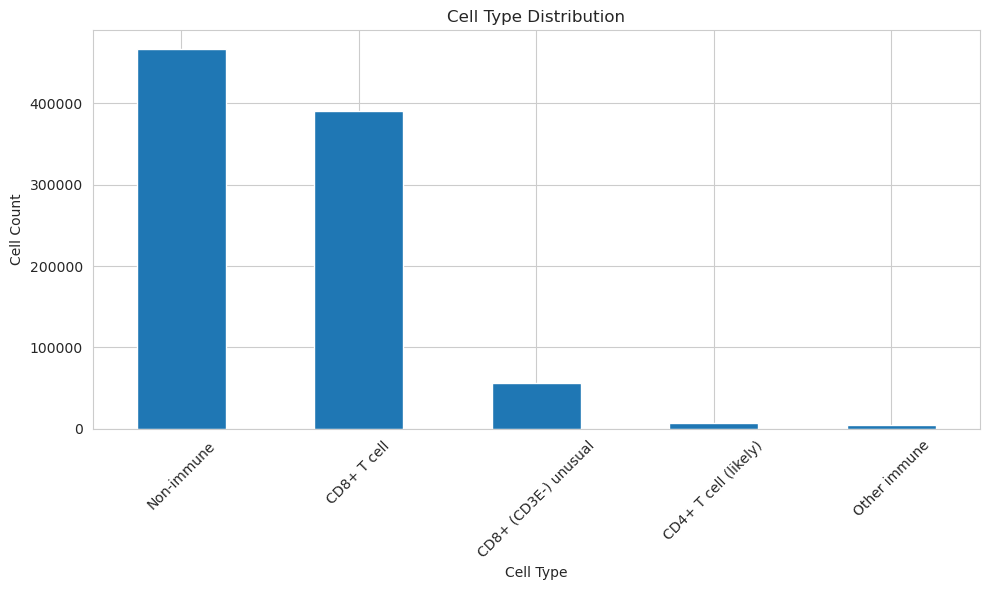

In [6]:
# Classify cells based on marker positivity
def classify_cell_type(row):
    cd45 = row['CD45_positive']
    cd3e = row['CD3E_positive']
    cd8a = row['CD8a_positive']
    
    if not cd45:
        return 'Non-immune'
    elif cd3e and cd8a:
        return 'CD8+ T cell'
    elif cd3e and not cd8a:
        return 'CD4+ T cell (likely)'
    elif cd8a and not cd3e:
        return 'CD8+ (CD3E-) unusual'
    else:
        return 'Other immune'

df['cell_type'] = df.apply(classify_cell_type, axis=1)

# Count by cell type
cell_type_counts = df['cell_type'].value_counts()
print("=== Cell Type Classification ===\n")
for cell_type, count in cell_type_counts.items():
    pct = 100 * count / len(df)
    print(f"{cell_type}: {count:,} ({pct:.2f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
cell_type_counts.plot(kind='bar', ax=ax)
ax.set_xlabel('Cell Type')
ax.set_ylabel('Cell Count')
ax.set_title('Cell Type Distribution')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Composite Intensity Analysis

/tmp/ipykernel_20661/539259911.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['cell_type'] == ct]['composite_intensity']


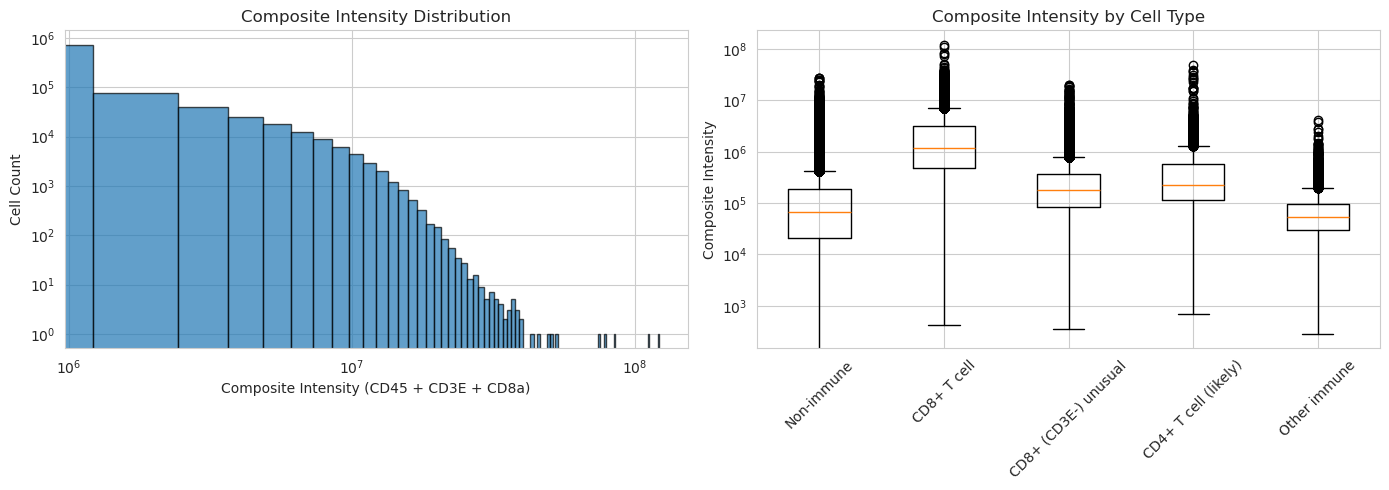

In [7]:
# Composite intensity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['composite_intensity'], bins=100, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Composite Intensity (CD45 + CD3E + CD8a)')
axes[0].set_ylabel('Cell Count')
axes[0].set_title('Composite Intensity Distribution')
axes[0].set_yscale('log')
axes[0].set_xscale('log')

# By cell type
axes[1].boxplot([df[df['cell_type'] == ct]['composite_intensity'] 
                 for ct in cell_type_counts.index], 
                labels=cell_type_counts.index)
axes[1].set_ylabel('Composite Intensity')
axes[1].set_title('Composite Intensity by Cell Type')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 6. Export Results

In [8]:
# Save classified cells
output_path = PROJECT_DIR / 'cellpose_output' / 'cell_intensities_classified.csv'
df.to_csv(output_path, index=False)
print(f"Saved classified results to: {output_path}")

# Summary by cell type
summary = df.groupby('cell_type').agg({
    'CD45_mean': ['mean', 'std'],
    'CD3E_mean': ['mean', 'std'],
    'CD8a_mean': ['mean', 'std'],
    'composite_intensity': ['mean', 'std'],
    'cell_area': ['mean', 'std'],
    'cell_id': 'count'
}).round(2)

print("\n=== Summary by Cell Type ===")
print(summary)

Saved classified results to: ../cellpose_output/cell_intensities_classified.csv

=== Summary by Cell Type ===
                     CD45_mean         CD3E_mean          CD8a_mean           \
                          mean     std      mean      std      mean      std   
cell_type                                                                      
CD4+ T cell (likely)    282.02  272.00    869.42  1343.35      3.16     1.60   
CD8+ (CD3E-) unusual    254.42  235.80     40.21    30.19    548.16  1418.13   
CD8+ T cell             777.52  782.63   3126.66  4359.42   1647.19  2522.48   
Non-immune               33.51   28.60    129.77   336.07    275.47   622.50   
Other immune            154.01   77.82     41.33    31.60      2.67     1.63   

                     composite_intensity             cell_area         cell_id  
                                    mean         std      mean     std   count  
cell_type                                                                       
CD4+ T